# Skin Cancer Triage with Deep Learning

## Import necessary libraries

In [1]:
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub

import ipywidgets as widgets
from IPython.display import display, clear_output

from google.colab import drive

print("Tensorflow version:", tf.__version__)
print("Available devices:", tf.config.list_physical_devices('GPU'))

Tensorflow version: 2.12.0
Available devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
tf.test.gpu_device_name() # if /device:GPU:0, then GPU is being used

'/device:GPU:0'

Make sure to enable GPU acceleration inside colab ([tutorial](https://www.tutorialspoint.com/google_colab/google_colab_using_free_gpu.htm)).

## I) Data preparation

The International Skin Imaging Collaboration (ISIC) is an international effort to improve melanoma diagnosis. The ISIC Archive contains the largest publicly available collection of quality controlled dermoscopic images of skin lesions.
Beginning in 2016, ISIC has sponsored annual challenges for the computer science community in association with leading computer vision conferences.

In this tutorial we will use the data made available for the 2016 edition of the challenge.

You can check the dataset description [here](https://challenge.isic-archive.com/landing/2016/41/).

### Option 1: Download dataset

In [ ]:
# !gdown https://drive.google.com/uc?id=1zGRAJQ_Hei6KTykqIA9OH-uGz-8fHbRO
# !echo "4acfbd61b18ba430f31f4b3f1229f0a4ab585e31  ISBI2016_ISIC_Part3B.zip" | shasum -c -
# !7z x ISBI2016_ISIC_Part3B.zip
# !ls ISBI2016_ISIC_Part3B

### Option 2: Mount from google drive

In [ ]:
# drive.mount('/content/drive', force_remount=True)
# !echo "4acfbd61b18ba430f31f4b3f1229f0a4ab585e31  /content/drive/MyDrive/Colab_Notebooks/ISBI2016_ISIC_Part3B.zip" | shasum -c -
# !7z x /content/drive/MyDrive/Colab_Notebooks/ISBI2016_ISIC_Part3B.zip
# !ls ISBI2016_ISIC_Part3B

In [4]:
DATA_DIR = 'ISBI2016_ISIC_Part3B'
CLASS_NAMES = ['benign', 'malignant']

### Analyze label repartition

In [5]:
# TODO as exercise

def load_labels(label_file):
  lab_df = pd.read_csv(label_file, names=['imageID', 'diagnosis'], header=None)
  lab_df.diagnosis.replace({i: c for i, c in enumerate(CLASS_NAMES)}, inplace=True)
  return lab_df

lab_train = load_labels(f'{DATA_DIR}/ISBI2016_ISIC_Part3B_Training_GroundTruth.csv')
lab_test = load_labels(f'{DATA_DIR}/ISBI2016_ISIC_Part3B_Test_GroundTruth.csv')

We observe a clear imbalance, which is similar between the train and test sets.

## II) Load dataset with Keras

In [6]:
SEED = 42
BATCH_SIZE = 16
BASE_IMAGE_SIZE = 384, 384
VALID_SIZE = 0.2

### Option 1: Restructure dataset to fit Keras data loading API

> Use Dataset objects if you have large datasets and you need to do distributed training

In [7]:
def restructure_dataset(source_dir, destination_dir, lab_df):
  labels = dict(zip(lab_df['imageID'], lab_df['diagnosis']))
  destination_dir = Path(destination_dir)
  # create category directories
  for image_path in Path(source_dir).glob("*.jpg"):
    category = labels[image_path.stem]
    category_dir = destination_dir / category
    category_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy(image_path, category_dir / image_path.name)

restructure_dataset(
    f'{DATA_DIR}/ISBI2016_ISIC_Part3B_Training_Data',
    f'{DATA_DIR}/train',
    lab_train
    )
restructure_dataset(
    f'{DATA_DIR}/ISBI2016_ISIC_Part3B_Test_Data',
    f'{DATA_DIR}/test',
    lab_test
    )

In [8]:
def build_dataset(data_dir, split_val=False, val_size=VALID_SIZE, seed=SEED,
                  shuffle=True, image_size=BASE_IMAGE_SIZE, batch_size=BATCH_SIZE):
  train = tf.keras.utils.image_dataset_from_directory(
      data_dir,
      validation_split=val_size if split_val else None,
      subset="training" if split_val else None,
      seed=seed,
      shuffle=shuffle,
      image_size=image_size,
      batch_size=batch_size)

  if split_val: # Split the dataset into training and validation sets
    val = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=val_size,
        subset="validation",
        seed=seed,
        shuffle=shuffle,
        image_size=image_size,
        batch_size=batch_size)
  else:
    val = None
  return train, val

train_ds, val_ds = build_dataset(f'{DATA_DIR}/train', split_val=True)
test_ds, _ = build_dataset(f'{DATA_DIR}/test', split_val=False, shuffle=False)
assert CLASS_NAMES == train_ds.class_names == val_ds.class_names == test_ds.class_names

Found 900 files belonging to 2 classes.
Using 720 files for training.
Found 900 files belonging to 2 classes.
Using 180 files for validation.
Found 379 files belonging to 2 classes.


### Option 2: Use sequence dataset object

> Use Sequence objects if you have large datasets and you need to do a lot of custom Python-side processing that cannot be done in TensorFlow (e.g. if you rely on external libraries for data loading or preprocessing).

In [ ]:
class ISICSequence(tf.keras.utils.Sequence):
    def __init__(self, img_dir, lab_df, split_val=False, subset='training',
                 val_size=VALID_SIZE, seed=SEED, shuffle=True,
                 image_size=BASE_IMAGE_SIZE, batch_size=BATCH_SIZE):
      self.current_idx = 0
      self.image_size = image_size
      self.batch_size = batch_size
      self.mapped_preprocess = lambda x, y: (x,y)
      lab_dict = dict(zip(lab_df['imageID'], lab_df['diagnosis']))
      self.img_paths = list(Path(img_dir).glob("*.jpg"))
      self.labels = [CLASS_NAMES.index(lab_dict[p.stem]) for p in self.img_paths]
      if shuffle:
        rng = np.random.RandomState(seed)
        rng.shuffle(self.img_paths)
        rng = np.random.RandomState(seed)
        rng.shuffle(self.labels)
      if split_val:
        assert subset in ('training', 'validation')
        num_val_samples = int(val_size * len(self.labels))
        if subset == 'training':
          self.img_paths = self.img_paths[:-num_val_samples]
          self.labels = self.labels[:-num_val_samples]
        else:
          self.img_paths = self.img_paths[-num_val_samples:]
          self.labels = self.labels[-num_val_samples:]

    def map(self, fn):
      self.mapped_preprocess=fn
      return self

    def __len__(self):
      return int(np.ceil(len(self.img_paths) / float(self.batch_size)))

    def __getitem__(self, idx):
      batch_x = self.img_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
      batch_x = [tf.keras.preprocessing.image.load_img(x, target_size=self.image_size) for x in batch_x]
      batch_x = [tf.keras.preprocessing.image.img_to_array(x) for x in batch_x]
      batch_y = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]
      return self.mapped_preprocess(np.array(batch_x), np.array(batch_y))

In [ ]:
train_ds = ISICSequence(f'{DATA_DIR}/ISBI2016_ISIC_Part3B_Training_Data', lab_train, split_val=True)
val_ds = ISICSequence(f'{DATA_DIR}/ISBI2016_ISIC_Part3B_Training_Data', lab_train, split_val=True, subset='validation')
test_ds = ISICSequence(f'{DATA_DIR}/ISBI2016_ISIC_Part3B_Test_Data', lab_test, shuffle=False)

### Data preprocessing & augmentation

In [9]:
DO_DATA_AUGM = True

def get_preprocessing_with_augm(rescale01, with_augm=DO_DATA_AUGM):
  if rescale01: # range [0,1]
    normalization = tf.keras.layers.Rescaling(scale=1./255)
  else: # range [-1,1]
    normalization = tf.keras.layers.Rescaling(scale=1./127.5, offset=-1)
  preprocessing = tf.keras.Sequential([normalization])
  if with_augm:
    data_augm = tf.keras.Sequential([])
    data_augm.add(tf.keras.layers.RandomRotation(45))
    data_augm.add(tf.keras.layers.RandomTranslation(0.1, 0.1))
    data_augm.add(tf.keras.layers.RandomZoom(0.1, 0.1))
    data_augm.add(tf.keras.layers.RandomFlip(mode="horizontal"))
    data_augm.add(tf.keras.layers.RandomContrast(0.1))
    preprocessing.add(data_augm)
  return preprocessing

def dataset_preprocess(train, val, test, rescale01=True):
  train_preprocess = get_preprocessing_with_augm(rescale01)
  tfm_train = train.map(lambda images, labels: (train_preprocess(images), labels))
  val_preprocess = get_preprocessing_with_augm(rescale01, with_augm=False)
  tfm_val = val.map(lambda images, labels: (val_preprocess(images), labels))
  tfm_test = test.map(lambda images, labels: (val_preprocess(images), labels))
  return tfm_train, tfm_val, tfm_test

tfm_train, tfm_val, tfm_test = dataset_preprocess(train_ds, val_ds, test_ds)

### Visualize batches

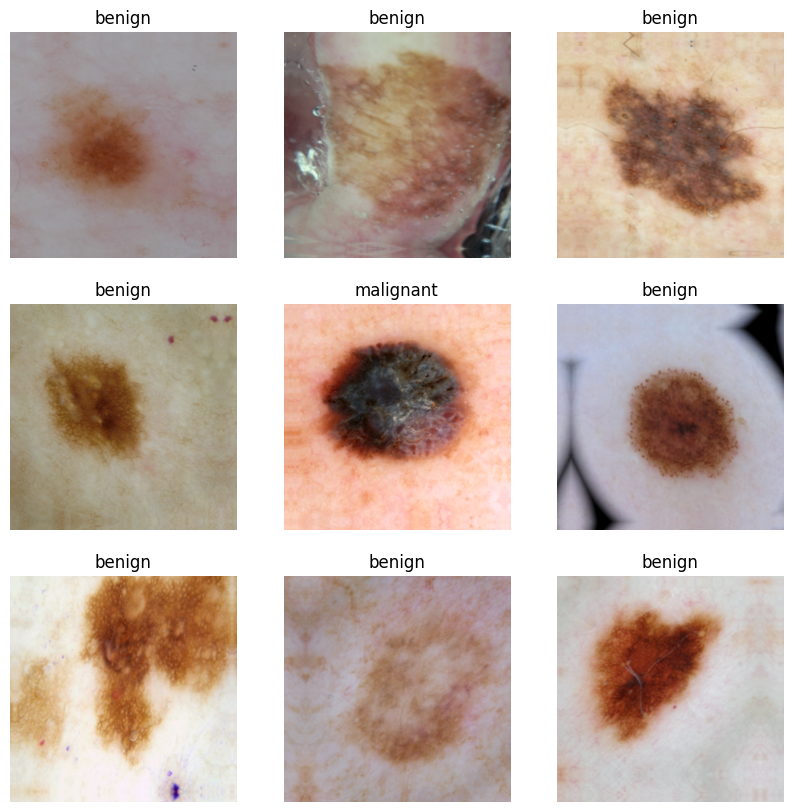

In [10]:
def show_image_grid(images, titles, n=3):
  if images.min() < 0: # rescaled [-1,1]
    images = (images + 1)/2
  plt.figure(figsize=(10, 10))
  for i, image, title in zip(range(n*n), images, titles):
    ax = plt.subplot(n, n, i + 1)
    ax.imshow(image)
    ax.set_title(title)
    ax.set_axis_off()

def show_samples_from_dataset(dataset):
  images, labels = next(iter(dataset))
  show_image_grid(images.numpy(), [CLASS_NAMES[li] for li in labels])

def dataset_browser_widget(show_samples):
  dataset_widget = widgets.ToggleButtons(
      options=[('Train', tfm_train), ('Valid', tfm_val), ('Test', tfm_test)],
      value=tfm_train,
      description='Dataset:'
  )
  out = widgets.interactive(show_samples, dataset=dataset_widget)
  button_widget = widgets.Button(description="New batch")
  button_widget.on_click(out.update)
  display(widgets.VBox([out, button_widget]))

dataset_browser_widget(show_samples_from_dataset)

## III) Model Creation - EfficientNet v2

In [11]:
DO_FINE_TUNE = True
MODEL_CLS = tf.keras.applications.efficientnet_v2.EfficientNetV2S
MODEL_HUB = "https://tfhub.dev/google/imagenet/efficientnet_v2_imagenet1k_s/feature_vector/2"
MODEL_INPUT_SIZE = 384, 384, 3 # RGB
assert MODEL_INPUT_SIZE[:-1] == BASE_IMAGE_SIZE

### Option 1: Using Tensorflow default implementation

In [12]:
# [-1, 1] range is expected
tfm_train, tfm_val, tfm_test = dataset_preprocess(train_ds, val_ds, test_ds, rescale01=False)
gradcam_preprocess = get_preprocessing_with_augm(rescale01=False, with_augm=False)

def create_model(net_class, input_shape, fine_tune=DO_FINE_TUNE):
  base_model = net_class(
      include_top=False,
      weights='imagenet',
      input_shape=input_shape,
      pooling='avg', # max or avg
      include_preprocessing=False
      )
  base_model.trainable = fine_tune

  model = tf.keras.Sequential([
      base_model,
      tf.keras.layers.Dense(1, activation='sigmoid') # 1 = number of layers
  ])
  model.build()
  return model

model = create_model(MODEL_CLS, MODEL_INPUT_SIZE)
model.summary()
# shape (x,features)

82420632/82420632 [==============================] - 4s 0us/step
Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-s (Functiona  (None, 1280)             20331360  
 l)                                                              
                                                                 
 dense (Dense)               (None, 1)                 1281      
                                                                 
Total params: 20,332,641
Trainable params: 20,178,769
Non-trainable params: 153,872
_________________________________________________________________


In [ ]:
model.layers[-2].summary()
"""
__________________________________________________________________________________________________
 Layer (type)                      Output Shape           Param #   Connected to                     
==================================================================================================
 input_1 (InputLayer)              [(None, 384, 384, 3)]  0         []                                   

 ...
 
 top_activation (Activation)       (None, 12, 12, 1280)   0         ['top_bn[0][0]']                                                                  
                                                                                                  
 avg_pool (GlobalAveragePooling2D)  (None, 1280)        0         ['top_activation[0][0]']         
                                                                                                                                       
==================================================================================================
Total params: 20,331,360
Trainable params: 20,177,488
Non-trainable params: 153,872
"""

### Option 2: Load model from TensorFlow Hub (incompatible with Grad-CAM in model testing)

Check [TensorFlow Hub](https://tfhub.dev/s?module-type=image-classification) for other architectures.

In [ ]:
# [0, 1] range is expected
tfm_train, tfm_val, tfm_test = dataset_preprocess(train_ds, val_ds, test_ds)
gradcam_preprocess = get_preprocessing_with_augm(rescale01=True, with_augm=False)

def create_model(hub_url, input_shape, fine_tune=DO_FINE_TUNE):
  model = tf.keras.Sequential([
      hub.KerasLayer(hub_url, trainable=fine_tune, name='arch', input_shape=input_shape),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])
  model.build()
  return model

model = create_model(MODEL_HUB, MODEL_INPUT_SIZE)
model.summary()

## IV) Train model

In [ ]:
EPOCHS = 45

def cache_dataset(dataset):
  # if type(dataset) is ISICSequence: # caching not supported
  if type(dataset) == 'ISICSequence': # caching not supported
    return dataset
  else:
    return dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=[
                  tf.keras.metrics.Precision(),
                  tf.keras.metrics.Recall(),
                  tf.keras.metrics.AUC(curve='PR')
                  ]
              )
hist = model.fit(
    cache_dataset(tfm_train),
    epochs=EPOCHS,
    validation_data=cache_dataset(tfm_val),
    class_weight={0: 1., 1: 4.}
    ).history

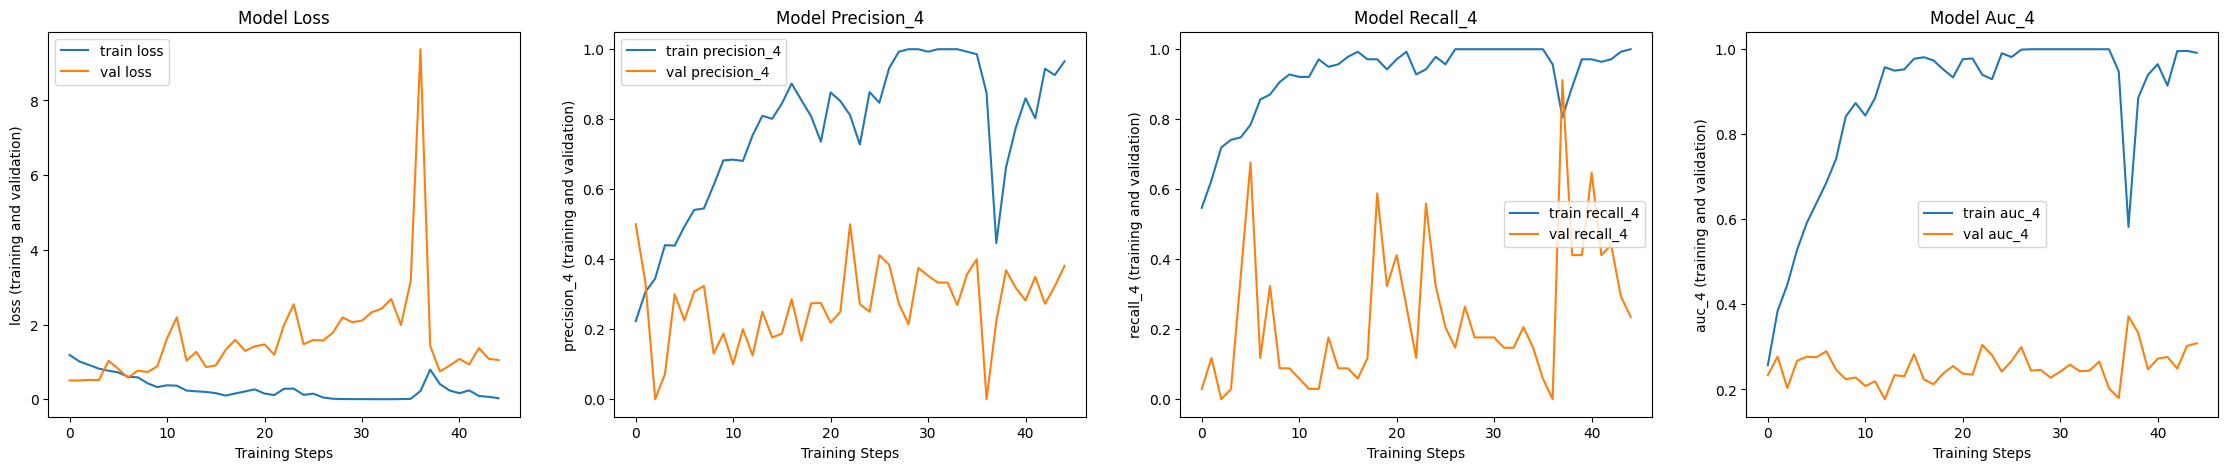

In [19]:
def plot_history(history, metrics_names):
  n_metrics = len(metrics_names)
  plt.figure(figsize=(7*n_metrics, 5))
  for i, key in enumerate(metrics_names):
    if key not in history: continue
    ax = plt.subplot(1, n_metrics, i + 1)
    ax.set_ylabel(f"{key} (training and validation)")
    ax.set_xlabel("Training Steps")
    ax.plot(history[key], label=f"train {key}")
    if f"val_{key}" in history:
      ax.plot(history[f"val_{key}"], label=f"val {key}")
    ax.legend()
    ax.set_title(f"Model {key.capitalize()}")

plot_history(hist, model.metrics_names)

## V) Test model

In [20]:
def compute_performance(model, ds_name, dataset):
  results = model.evaluate(dataset)
  print(", ".join([f"{ds_name} {name}: {result:.3}" for name, result in zip(model.metrics_names, results)]).capitalize())

compute_performance(model, 'valid', tfm_val)
compute_performance(model, 'test', tfm_test)

12/12 [==============================] - 4s 198ms/step - loss: 1.0499 - precision_4: 0.3810 - recall_4: 0.2353 - auc_4: 0.3085
Valid loss: 1.05, valid precision_4: 0.381, valid recall_4: 0.235, valid auc_4: 0.308
24/24 [==============================] - 9s 390ms/step - loss: 0.8769 - precision_4: 0.4333 - recall_4: 0.1733 - auc_4: 0.3370
Test loss: 0.877, test precision_4: 0.433, test recall_4: 0.173, test auc_4: 0.337


### Visualize predictions

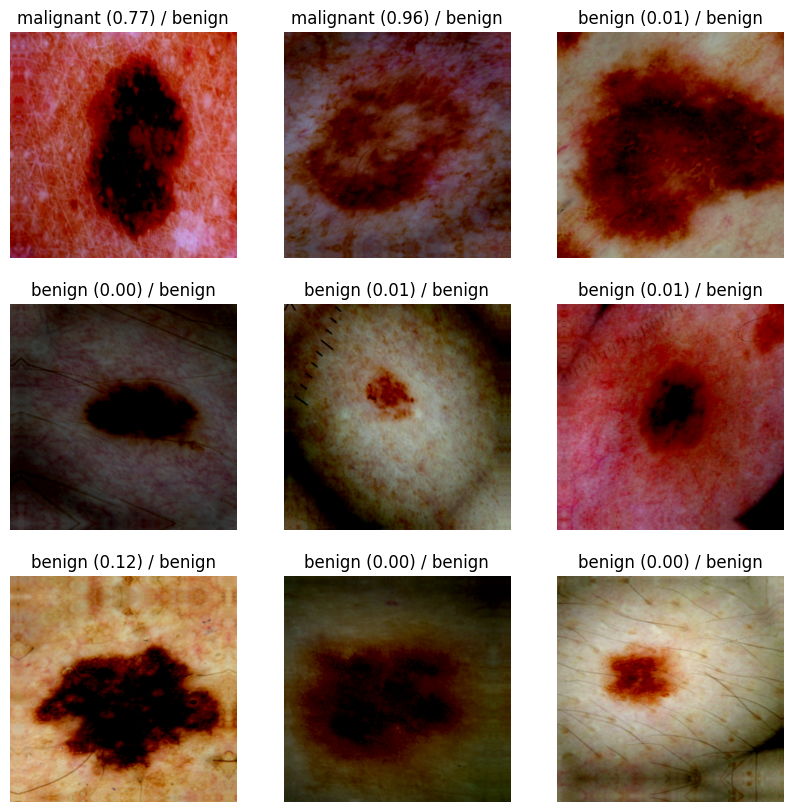

In [21]:
def show_dataset_predictions(dataset):
  images, true_labels = next(iter(dataset))
  predictions = model.predict(images)
  true_labels = [f"{CLASS_NAMES[gt]}" for gt in true_labels]
  predicted_labels = [f"{CLASS_NAMES[int(pred > .5)]} ({pred:.2f})" for preds in predictions for pred in preds]
  titles = [f"{pred} / {gt}" for gt, pred in zip(true_labels, predicted_labels)]
  show_image_grid(images.numpy(), titles)

dataset_browser_widget(show_dataset_predictions)

### Grad-CAM

Check original [source](https://keras.io/examples/vision/grad_cam/)

In [22]:
def get_img_array(img_path, size):
  img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
  # `array` is a float32 Numpy array of shape (h, w, 3)
  array = tf.keras.preprocessing.image.img_to_array(img)
  # We add a dimension to transform our array into a "batch" of size (1, h, w, 3)
  array = np.expand_dims(array, axis=0)
  # Apply preprocessing
  return gradcam_preprocess(array)

def get_last_nth_conv_layer(model, n=1):
  conv_layers = filter(lambda x: isinstance(x, tf.keras.layers.Conv2D), model.layers)
  return list(conv_layers)[-n].name

def make_gradcam_heatmap(img_path, size, model, last_conv_layer_name=None, pred_index=None):
  # last 2nd layer is the base model
  model = model.layers[-2]
  img_array = get_img_array(img_path, size)
  if last_conv_layer_name is None:
    last_conv_layer_name = get_last_nth_conv_layer(model)
  # First, we create a model that maps the input image to the activations
  # of the last conv layer as well as the output predictions
  grad_model = tf.keras.models.Model(
      [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
  )

  # Then, we compute the gradient of the top predicted class for our input image
  # with respect to the activations of the last conv layer
  with tf.GradientTape() as tape:
      last_conv_layer_output, preds = grad_model(img_array)
      if pred_index is None:
          pred_index = tf.argmax(preds[0])
      class_channel = preds[:, pred_index]

  # This is the gradient of the output neuron (top predicted or chosen)
  # with regard to the output feature map of the last conv layer
  grads = tape.gradient(class_channel, last_conv_layer_output)

  # This is a vector where each entry is the mean intensity of the gradient
  # over a specific feature map channel
  pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

  # We multiply each channel in the feature map array
  # by "how important this channel is" with regard to the top predicted class
  # then sum all the channels to obtain the heatmap class activation
  last_conv_layer_output = last_conv_layer_output[0]
  heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap)

  # For visualization purpose, we will also normalize the heatmap between 0 & 1
  heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
  return heatmap.numpy()

def display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
    # Load the original image
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    plt.imshow(superimposed_img)

<ipython-input-22-fea9833ee9ca>:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = cm.get_cmap("jet")


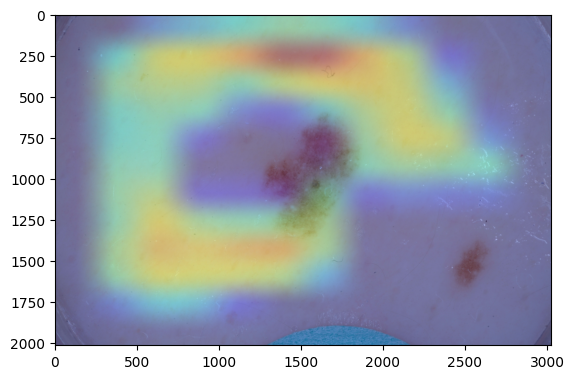

In [23]:
img_path = f'{DATA_DIR}/ISBI2016_ISIC_Part3B_Test_Data/ISIC_0007693.jpg'
display_gradcam(img_path, make_gradcam_heatmap(img_path, BASE_IMAGE_SIZE, model))

## VI) Save/Load model

In [24]:
drive.mount('/content/drive')
model.save('efficientnet2s_isic')
#!cp -r efficientnet2s_isic /content/drive/MyDrive/Colab_Notebooks/efficientnet2s_isic

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
m2 = tf.keras.models.load_model('efficientnet2s_isic')
compute_performance(m2, 'test', test_ds)

24/24 [==============================] - 13s 288ms/step - loss: 50.4910 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00 - auc_4: 0.2061
Test loss: 50.5, test precision_4: 0.0, test recall_4: 0.0, test auc_4: 0.206
